<a href="https://colab.research.google.com/github/nikunj474/nikunj474/blob/main/Big_data_hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW3 -- MAKE A COPY BEFORE YOU BEGIN

In [1]:
!pip install --upgrade "git+https://github.com/RyanMarcus/penngrader2.git@8a34a2c"
!pip install polars_ds



  Cloning https://github.com/RyanMarcus/penngrader2.git (to revision 8a34a2c) to /tmp/pip-req-build-ynd5iyhp
  Running command git clone --filter=blob:none --quiet https://github.com/RyanMarcus/penngrader2.git /tmp/pip-req-build-ynd5iyhp
  Running command git checkout -q 8a34a2c
  Resolved https://github.com/RyanMarcus/penngrader2.git to commit 8a34a2c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 76.7 MB/s eta 0:00:00
  Created wheel for penngrader2: filename=penngrader2-0.1.0-py3-none-any.whl size=46435 sha256=0dfcb6f61cd3305aa5acf7fbd31d60b152e614c3272b5fd39ae68fb3d407995b
  Stored in directory: /tmp/pip-ephem-wheel-cache-p8hz6me6/wheels/83/87/cd/a273c0a2173e336917ac2bbf9fd2fea0d76136b023f4d5d4b5
Successfully built penngrader2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Setup

Change the `penngrader2.login` call below to your student ID. Do not change anything else in the below cell.

In [2]:
import penngrader2
import numpy as np
import polars as pl
import polars_ds as pds

penngrader2.configure("https://pg2.rmarcus.info/", api_key="bxP7tLb8S7/KGbZaQrJxJNYEzYymrvNW")
penngrader2.login(20602706)


# Part 1: Computing $\pi$

Let's compute $\pi$ using the power of computation. Imagine a unit square (a 1x1 square) with a circle of radius 0.5 inscribed inside.

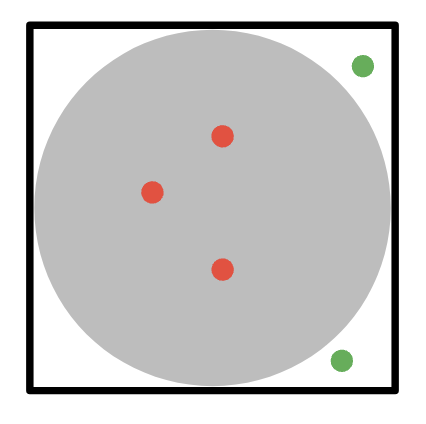

Suppose we randomly sample some points from inside the unit square, as shown above. Some of the points will land inside the circle (red), while others will be inside the square but outside the circle (green).

We know that the area of the circle divided by the area of the square is related to $\pi$ by:

$\frac{\mbox{circle area}}{\mbox{square area}} = \frac{\pi r^2}{1}$

Solving for $\pi$ gives:

$\pi = 4 \frac{\mbox{circle area}}{\mbox{square area}}$

We can compute circle area/square area using a simple Monte Carlo simulation. Sampling a random point uniformly inside the square is easy, we just pick a random value between 0 and 1 twice. Then, we can see if that random point is inside the circle. The (num points inside circle / total points) is an approximation of circle area/square area.

## 1.1 Iterative simulation (5 points)

Here's a simple Python program that computes $\pi$ using the technique above. Unfortunately, it is not very accurate right now. Adjust the iteration count to 10 million (10_000_000) and run the code. Observe the accuracy of the answer and the time spent on the calculation.

In [3]:
%%time
import random
random.seed(42)

pts_in_circle = 0
pts_in_square = 0
for _ in range(10000000):
  x = random.random() - 0.5
  y = random.random() - 0.5

  if x**2 + y**2 <= 0.25:
    pts_in_circle += 1
  pts_in_square += 1

print(4.0 * pts_in_circle / pts_in_square)

3.1421736
CPU times: user 7.72 s, sys: 20 ms, total: 7.74 s
Wall time: 8 s


In [4]:
# WARNING: YOU MUST RUN THIS CELL IMMEDIATELY AFTER RUNNING THE CELL ABOVE. If
# you run some cell in between, you will get a nonsense grade.

src = In[len(In) - 2]
penngrader2.submit("hw3", "problem1_1", src)

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5. Correct


## 1.2 Vectorized simulation (15 points)

Let's rewrite the above simulation using vectorization with `numpy`. Your code should not use any Python iteration constructs (such as `for`, `while`, `filter`, `map`, etc.).

Hint: you can use `np.random.rand(10_000_000)` to generate 10M random values between 0 and 1.

Use `%%time` to measure how long your simulation takes to run. Print out your estimate of $\pi$ at the end.

In [5]:
%%time
import numpy as np

# Generate 10 million random x and y coordinates between -0.5 and 0.5
x = np.random.rand(10_000_000) - 0.5
y = np.random.rand(10_000_000) - 0.5

# Check if each point is inside the circle of radius 0.5
inside_circle = (x**2 + y**2) <= 0.25

# Calculate the estimate of pi
pi_est = 4.0 * np.sum(inside_circle) / 10_000_000

print(pi_est)


3.1416252
CPU times: user 251 ms, sys: 101 ms, total: 353 ms
Wall time: 357 ms


In [6]:
# WARNING: YOU MUST RUN THIS CELL IMMEDIATELY AFTER RUNNING THE CELL ABOVE. If
# you run some cell in between, you will get a nonsense grade.

src = In[len(In) - 2]
penngrader2.submit("hw3", "problem1_2", src)

Rate limited. Waiting 12s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 15/15. 



# Part 2: Property data

Let's analyze some real estate data from California. We'll fetch the data in [Parquet format](https://www.databricks.com/blog/what-is-parquet) and load it into a Pandas dataframe.

In [7]:
!wget -nc https://upenn.ferric.systems/cis5450/ca_housing.parquet

--2026-03-28 02:16:39--  https://upenn.ferric.systems/cis5450/ca_housing.parquet
Resolving upenn.ferric.systems (upenn.ferric.systems)... 172.67.213.240, 104.21.23.216, 2606:4700:3035::ac43:d5f0, ...
Connecting to upenn.ferric.systems (upenn.ferric.systems)|172.67.213.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 643894 (629K) [application/octet-stream]
Saving to: ‘ca_housing.parquet’

ca_housing.parquet  100%[===================>] 628.80K   776KB/s    in 0.8s    

2026-03-28 02:16:41 (776 KB/s) - ‘ca_housing.parquet’ saved [643894/643894]



Next, we load it in Pandas:

In [8]:
import pandas as pd
df = pd.read_parquet("ca_housing.parquet")
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,$83.3k,41.0,6.984127,1.023810,0.3k,2.555556,37.88,-122.23,$452.6k
1,$83k,21.0,6.238137,0.971880,2.4k,2.109842,37.86,-122.22,$358.5k
2,$72.6k,52.0,8.288136,1.073446,0.5k,2.802260,37.85,-122.24,$352.1k
3,$56.4k,52.0,5.817352,1.073059,0.6k,2.547945,37.85,-122.25,$341.3k
4,$38.5k,52.0,6.281853,1.081081,0.6k,2.181467,37.85,-122.25,$342.2k
...,...,...,...,...,...,...,...,...,...
20635,$15.6k,25.0,5.045455,1.133333,0.8k,2.560606,39.48,-121.09,$78.1k
20636,$25.6k,18.0,6.114035,1.315789,0.4k,3.122807,39.49,-121.21,$77.1k
20637,$17k,17.0,5.205543,1.120092,1k,2.325635,39.43,-121.22,$92.3k
20638,$18.7k,18.0,5.329513,1.171920,0.7k,2.123209,39.43,-121.32,$84.7k


## 2.1 Cleaning housing data (5 points)

The housing data has these columns:

* `MedInc`, the median household income in a population block
* `HouseAge`, the median age of a home in a population block
* `AveRooms`, the average number of rooms in a home in a population block
* `AveBedrms`, the average number of bedrooms in a home in the population block
* `Population` , the size of the population block (number of people)
* `AveOccup`, the average number of people in a home in a population block
* `Latitude` and `Longitude` of the population block's center
* `MedHouseVal`, the median home value in the population block

Let's clean the data -- first, transform `MedInc`, `MedHouseVal`, and `Population` into integer columns with the correct values. Afterwards, sort the dataframe by `MedInc` ascending, breaking ties with `HouseAge` ascending, and reset the index.

Save your cleaned dataframe as `ca_housing_clean`.

In [9]:
ca_housing_clean = df.copy()

# Clean string columns and convert to int
for col in ['MedInc', 'MedHouseVal', 'Population']:
    ca_housing_clean[col] = (ca_housing_clean[col].str.replace('$', '', regex=False)
                                                  .str.replace('k', '', regex=False)
                                                  .astype(float) * 1000).astype(int)

# Sort by MedInc and HouseAge ascending
ca_housing_clean = ca_housing_clean.sort_values(by=['MedInc', 'HouseAge'], ascending=[True, True])

# Reset the index
ca_housing_clean = ca_housing_clean.reset_index(drop=True)

ca_housing_clean


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,5000,10.0,6.740000,2.040000,100,2.160000,34.69,-116.90,55000
1,5000,15.0,11.596491,2.561404,100,2.298246,40.43,-123.32,56700
2,5000,16.0,21.631579,6.000000,0,1.368421,39.42,-122.89,73500
3,5000,23.0,6.054545,1.672727,200,3.600000,36.09,-119.99,100000
4,5000,28.0,7.677419,1.870968,100,4.580645,34.15,-118.08,500000
...,...,...,...,...,...,...,...,...,...
20635,150000,52.0,8.710145,1.028986,400,2.956522,34.07,-118.41,500000
20636,150000,52.0,8.000000,0.997333,1100,3.048000,34.04,-118.50,500000
20637,150000,52.0,7.994475,1.027624,500,2.668508,37.79,-122.44,500000
20638,150000,52.0,8.000000,1.000000,0,13.000000,37.79,-122.50,500000


In [10]:
penngrader2.submit("hw3", "problem2_1", ca_housing_clean.head().to_json())

Rate limited. Waiting 6s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5. Correct answer.


## 2.2 Plot a panel (5 points)

Let's plot a panel of plots from this dataset to understand some of the basic relationships. Using `matplotlib`, create a single figure with 3 scatterplots with grid lines laid out in a row. Make the points transparent (alpha=0.25) to help visualize the mass.

Plot:

* MedInc vs MedHouseVal
* Population vs AveOccup
* HouseAge vs MedHouseVal

Once you see the plots, look for any data oddities in the MedHouseVal or HouseAge columns. Remove them from your dataset. For example, if a particular value is clipped at a certain maximum, remove values at that maximum. Remove any rows where `AveOccup` is greater than or equal to the 99.9th percentile of the original cleaned data (after the previous cleaning step, but before this one).

Afterwards, replot your fixed data and save your plot as "plot.jpg".

Call the cleaned data frame (with values dropped) `ca_housing_clean` again.

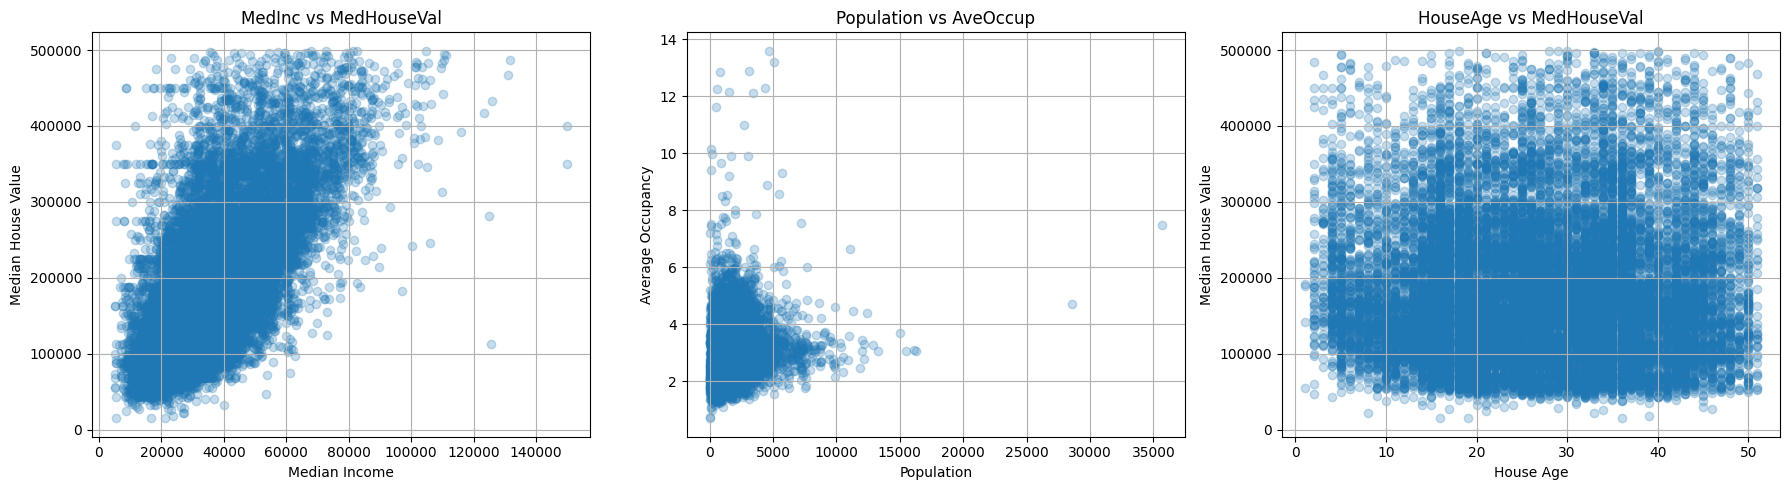

In [11]:
from matplotlib import pyplot as plt

# Calculate the 99.9th percentile of AveOccup on the original cleaned data
occ_threshold = ca_housing_clean['AveOccup'].quantile(0.999)

# Identify the clipped maximums
max_med_house_val = ca_housing_clean['MedHouseVal'].max()
max_house_age = ca_housing_clean['HouseAge'].max()

# Clean the dataset by removing the clipped oddities and extreme AveOccup values
ca_housing_clean = ca_housing_clean[
    (ca_housing_clean['MedHouseVal'] < max_med_house_val) &
    (ca_housing_clean['HouseAge'] < max_house_age) &
    (ca_housing_clean['AveOccup'] < occ_threshold)
]

# Plot the fixed data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MedInc vs MedHouseVal
axes[0].scatter(ca_housing_clean['MedInc'], ca_housing_clean['MedHouseVal'], alpha=0.25)
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Median House Value')
axes[0].set_title('MedInc vs MedHouseVal')
axes[0].grid(True)

# Population vs AveOccup
axes[1].scatter(ca_housing_clean['Population'], ca_housing_clean['AveOccup'], alpha=0.25)
axes[1].set_xlabel('Population')
axes[1].set_ylabel('Average Occupancy')
axes[1].set_title('Population vs AveOccup')
axes[1].grid(True)

# HouseAge vs MedHouseVal
axes[2].scatter(ca_housing_clean['HouseAge'], ca_housing_clean['MedHouseVal'], alpha=0.25)
axes[2].set_xlabel('House Age')
axes[2].set_ylabel('Median House Value')
axes[2].set_title('HouseAge vs MedHouseVal')
axes[2].grid(True)

plt.tight_layout()
fig.savefig("plot.jpg")
plt.show()


In [12]:
import base64
with open('plot.jpg', 'rb') as image_file:
    img = base64.b64encode(image_file.read()).decode('utf-8')

penngrader2.submit("hw3", "problem2_2", {"img": img, "rc": len(ca_housing_clean)})

Rate limited. Waiting 10s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Fetched ground truth
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 5/5. 



## 2.3 SLR (5 points)

Let's use simple linear regression to understand a few relationships. First, use simple linear regression to measure the average increase in our response variables when there is a unit increase in our input variables. Compute this value for:

* A 1 dollar increase in median income vs. median home value (`medinc_to_medval`)
* A 1 person increase in population vs. average occupancy (`pop_to_occ`)
* A 1 year increase in median home age vs. median household value (`medage_to_medval`)

Make sure to extract the coefficient, don't just return the whole coefficient array.

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
# TODO

# 1 dollar increase in median income vs. median home value
model_medinc = LinearRegression().fit(ca_housing_clean[['MedInc']], ca_housing_clean['MedHouseVal'])
medinc_to_medval = model_medinc.coef_[0]

model_pop = LinearRegression().fit(ca_housing_clean[['Population']], ca_housing_clean['AveOccup'])
pop_to_occ = model_pop.coef_[0]

model_medage = LinearRegression().fit(ca_housing_clean[['HouseAge']], ca_housing_clean['MedHouseVal'])
medage_to_medval = model_medage.coef_[0]


(medinc_to_medval, pop_to_occ, medage_to_medval)


(np.float64(4.043598036511597),
 np.float64(0.00011924492154395062),
 np.float64(115.65029093394281))

In [15]:
penngrader2.submit("hw3", "problem2_3", [medinc_to_medval, pop_to_occ, medage_to_medval])

Rate limited. Waiting 9s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 2.4 Dealing with geographic data (15 points)

Here's a plot of our cleaned dataset's longitude vs. latitude:

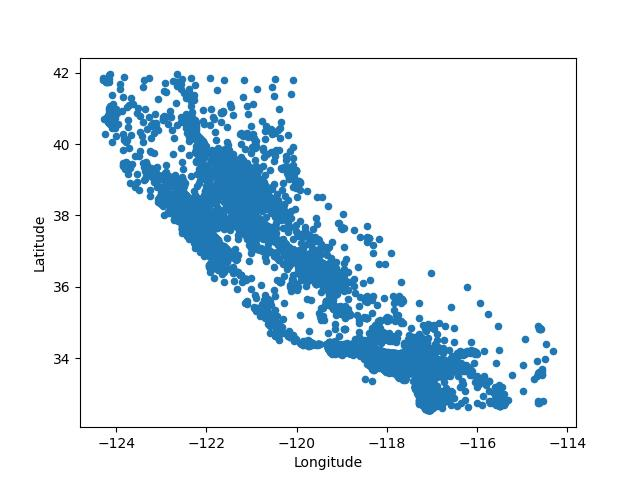

Notice that the data is in the shape of California (slightly skewed due to our flat projection). The longitude and latitude alone don't really make sense as features by themselves, because a longitude of -118 is coastal in San Diego, but inland in Northern California (possibly in Nevada).

Let's invent a new feature -- `is_coastal` -- that will be `True` if a population block is close to the coast, and `False` otherwise.

We'll use a simple algorithm to find the coastline. Split the data into 100 latitude bins of equal height (see `pd.cut` and `np.linspace`). For each bin, find the western-most point (lowest longitude of the bin with mean latitude of the points in the bin). Call this set of 100 points the "coastline set." Then, for every point in the dataset, compute its distance to the nearest point in the coastline set. If the point is within 10 miles of a coastal point, call it coastal. Otherwise, consider it non-coastal.

You can compare each housing block to a set of points by taking the cross product.

Combine your new feature with `ca_housing_clean`.

You may find it helpful to plot the coastal and non-coastal cities on a scatter plot.

In [16]:
# example of computing distance between two points on Earth (if it's too slow
# to use with .apply, you might have to vectorize it!)
def haversine_miles(pt1, pt2):
  lat1, lon1 = pt1
  lat2, lon2 = pt2

  lat1 = np.radians(lat1)
  lon1 = np.radians(lon1)
  lat2 = np.radians(lat2)
  lon2 = np.radians(lon2)

  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
  c = 2 * np.arcsin(np.sqrt(a))

  earth_radius_miles = 3958.8
  return earth_radius_miles * c

p1 = (37.7749, -122.4194)   # San Francisco
p2 = (34.0522, -118.2437)   # Los Angeles

haversine_miles(p1, p2)


np.float64(347.4252928066673)

/tmp/ipykernel_26170/2742745906.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca_housing_clean['lat_bin'] = pd.cut(ca_housing_clean['Latitude'], bins=100)
/tmp/ipykernel_26170/2742745906.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca_housing_clean['is_coastal'] = min_distances <= 10.0


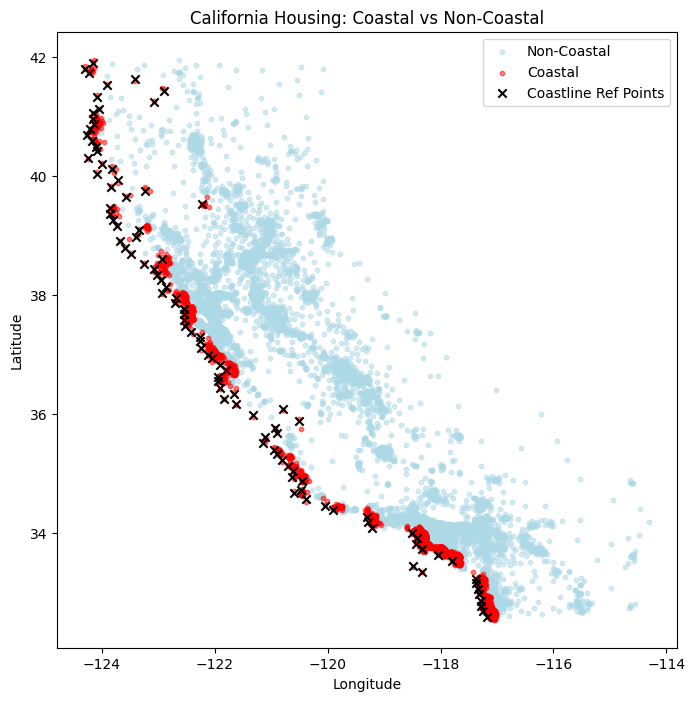

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Create 100 latitude bins of equal height
ca_housing_clean['lat_bin'] = pd.cut(ca_housing_clean['Latitude'], bins=100)

# 2. Find the coastline points for each bin (mean latitude, min longitude)
coastline_df = ca_housing_clean.groupby('lat_bin', observed=False).agg(
    mean_lat=('Latitude', 'mean'),
    min_lon=('Longitude', 'min')
).dropna()
coastline_set = coastline_df.values  # Shape: (M, 2) where M is up to 100

# 3. Vectorized Haversine distance function
def haversine_miles_vec(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 3958.8 * c

# Setup arrays for broadcasting to compute all pairs of distances efficiently
lats1 = ca_housing_clean['Latitude'].values[:, np.newaxis]  # (N, 1)
lons1 = ca_housing_clean['Longitude'].values[:, np.newaxis] # (N, 1)
lats2 = coastline_set[:, 0]                                 # (M,)
lons2 = coastline_set[:, 1]                                 # (M,)

# Compute distance matrix (N x M)
distances = haversine_miles_vec(lats1, lons1, lats2, lons2)

# 4. Find distance to the nearest coastline point
min_distances = distances.min(axis=1)

# 5. Label as coastal if within 10 miles
ca_housing_clean['is_coastal'] = min_distances <= 10.0

# Clean up the temporary bin column
ca_housing_clean = ca_housing_clean.drop(columns=['lat_bin'])

# 6. Plot the results
plt.figure(figsize=(8, 8))
plt.scatter(ca_housing_clean['Longitude'][~ca_housing_clean['is_coastal']],
            ca_housing_clean['Latitude'][~ca_housing_clean['is_coastal']],
            c='lightblue', label='Non-Coastal', alpha=0.5, s=10)
plt.scatter(ca_housing_clean['Longitude'][ca_housing_clean['is_coastal']],
            ca_housing_clean['Latitude'][ca_housing_clean['is_coastal']],
            c='red', label='Coastal', alpha=0.5, s=10)
plt.scatter(coastline_set[:, 1], coastline_set[:, 0], c='black', label='Coastline Ref Points', marker='x')
plt.legend()
plt.title('California Housing: Coastal vs Non-Coastal')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [18]:
penngrader2.submit("hw3", "problem2_4",
                   ca_housing_clean[ca_housing_clean["is_coastal"]].to_json())

Rate limited. Waiting 10s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 15/15.


## 2.5 Hypothesis test (10 points)

Let's test the hypothesis that coastal homes have a higher value than non-coastal homes. We'll pick $\alpha = 0.05$.

Write a simulation-based hypothesis test to help answer this question. Assume the `is_coastal` labels are exchangeable in the null world. Run at least 100k iterations.

Once you observe your P-value, fill out the "interpretation" variable with your interpretation and conclusion from this experiment.

In [19]:
import numpy as np

df = ca_housing_clean.copy()

# Calculate observed difference in means
coastal_mean = df[df['is_coastal']]['MedHouseVal'].mean()
non_coastal_mean = df[~df['is_coastal']]['MedHouseVal'].mean()
observed_diff = coastal_mean - non_coastal_mean

# Simulation settings
n_iterations = 100_000
simulated_diffs = np.zeros(n_iterations)

values = df['MedHouseVal'].values.copy()
n_coastal = df['is_coastal'].sum()
n_total = len(values)
total_sum = values.sum()

# Run simulation
for i in range(n_iterations):
    np.random.shuffle(values)
    sim_coastal_sum = values[:n_coastal].sum()
    sim_coastal_mean = sim_coastal_sum / n_coastal
    sim_non_coastal_mean = (total_sum - sim_coastal_sum) / (n_total - n_coastal)
    simulated_diffs[i] = sim_coastal_mean - sim_non_coastal_mean

# Calculate empirical P-value
empirical_p = np.sum(simulated_diffs >= observed_diff) / n_iterations

print(f"Observed difference: {observed_diff:.2f}")
print(f"Empirical P-value: {empirical_p}")


Observed difference: 51494.68
Empirical P-value: 0.0


In [20]:
# WARNING, only run this cell immediately after you run your simulation.

interpretation = """
Based on my empirical P value of < 1/100k, I reject the null hypothesis.
"""

src = In[len(In) - 2]
penngrader2.submit("hw3", "problem2_5",
                   {"code": src, "interp": interpretation})

[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 10/10. 



## 2.6 Confidence intervals (5 points)

Now that we've established whether or not being coastal, on its own, indicates a significantly different home value, let's try to measure exactly how much being coastal improves the value of a home *while accounting for the other variables in the dataset*. Your regression should account for:

* `MedInc`, `HouseAge`, `AveRooms`,	`AveBedrms`, `Population`, `AveOccup`, `is_coastal`

To do this, we'll compute confidence intervals on the regression coefficient for the `is_coastal` indicator variable. Do this by bootstrapping: repeatedly take samples of your data with replacement, measure the slope, and then compute an empirical 95% confidence interval. Run 10k iterations.

Save your interval as `ci = (lb, ub)`.

Note: in general, you should run a hypothesis test for the MLR as well, but we'll skip it for now.

In [22]:
%%time
from sklearn.linear_model import LinearRegression
import numpy as np

features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'is_coastal']
X = ca_housing_clean[features].astype(float).values
y = ca_housing_clean['MedHouseVal'].astype(float).values

n_iterations = 10000
n_size = len(ca_housing_clean)
coastal_coefs = np.zeros(n_iterations)

for i in range(n_iterations):
    # Sample with replacement
    indices = np.random.choice(n_size, size=n_size, replace=True)
    X_sample = X[indices]
    y_sample = y[indices]

    # Fit the Multiple Linear Regression model
    model = LinearRegression()
    model.fit(X_sample, y_sample)

    # The coefficient for 'is_coastal' is at the last index (6)
    coastal_coefs[i] = model.coef_[6]

# Compute the 95% confidence interval (2.5th and 97.5th percentiles)
lb = np.percentile(coastal_coefs, 2.5)
ub = np.percentile(coastal_coefs, 97.5)
ci = (lb, ub)
print("95% Confidence Interval for is_coastal:", ci)


95% Confidence Interval for is_coastal: (np.float64(30375.215542872626), np.float64(35402.51842296292))
CPU times: user 2min 30s, sys: 215 ms, total: 2min 30s
Wall time: 1min 26s


In [23]:
penngrader2.submit("hw3", "problem2_6", {"lb": ci[0], "ub": ci[1]})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 2.7 Speeding up CIs (10 points)

Your free tier Colab environment has two cores, but so far we have only used one. We can use Polars to take advantage of both cores.

Rewrite your CI calculation using Polars. You can use [`pds.lin_reg`](https://polars-ds-extension.readthedocs.io/en/latest/expr_linear.html) to do a linear regression directly in Polars. Make sure to add a bias term, and pay attention to the layout of the coefs. Again, do 10k iterations. Save the result as tuple `ci_pl`.

Measure the time of both functions and compare their speeds. You won't get exactly the same answer as before due to small differences in how scikit-learn and polars_ds computes LR.

In [24]:
pl_df = pl.from_pandas(ca_housing_clean)

In [28]:
%%time
import numpy as np
import polars as pl

features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'is_coastal']
n_iterations = 10000

coastal_coefs_pl = np.zeros(n_iterations)

# Cast the relevant columns to Float64 to avoid the 'All columns need to be numeric' error
numeric_pl_df = pl_df.select([pl.col(c).cast(pl.Float64) for c in features + ["MedHouseVal"]])

for i in range(n_iterations):
    # Sample with replacement using Polars
    sample_df = numeric_pl_df.sample(fraction=1.0, with_replacement=True)

    # Run linear regression directly in Polars
    # Unpack the features and provide the target as a keyword argument
    coefs = sample_df.select(pds.lin_reg(*features, target="MedHouseVal", add_bias=True)).item()
    coastal_coefs_pl[i] = coefs[6]

lb = np.percentile(coastal_coefs_pl, 2.5)
ub = np.percentile(coastal_coefs_pl, 97.5)
ci_pl = (lb, ub)
print("95% Confidence Interval for is_coastal (Polars):", ci_pl)


95% Confidence Interval for is_coastal (Polars): (np.float64(30358.64570538334), np.float64(35432.0680560129))
CPU times: user 22.2 s, sys: 3.01 s, total: 25.2 s
Wall time: 20.8 s


In [29]:
# WARNING, only run this cell immediately after you run your simulation.
src = In[len(In) - 2]
penngrader2.submit("hw3", "problem2_7",
                   {"src": src, "ci_pl": ci_pl})

[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 10/10. 



# Submit

That's all! Please download both the `homework3.ipynb` and `homework3.py` versions of your notebook and submit them to Gradescope. Make sure your student ID was correctly set at the top of the notebook.